In [ ]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import scipy
import pandas as pd

: 

# Taller de diferenciación numérica

**Métodos Computacionales en Ingeniería (MCEI_M)** · Escuela Colombiana de Ingeniería Julio Garavito

**Presentado Por:** Angel Fabian Pedreros · Laura Camila Andrade Campos

**Docente:** Ing. Alexander Pérez Ruiz, PhD.

## Propósito

Estimación de la velocidad lineal $v$ y angular $\omega$ de un robot de cinemática diferencial a partir de muestras discretas de posición $(x, y, t)$.

Cadena de cálculo: $(x, y) \rightarrow (\dot{x}, \dot{y}) \rightarrow (v, \theta) \rightarrow \omega$

### 3. Datos del robot

Se generan 51 muestras equiespaciadas, $t_i = 0.2\,i$ con $i = 0,\dots,50$, a partir de:

$$x(t) = 0.08\,t^2 + 0.40\sin(0.45\,t), \qquad y(t) = 0.50\,t + 0.30\,\bigl(1-\cos(0.45\,t)\bigr)$$

#### 3.1 Generación del archivo CSV

In [5]:


# 51 muestras equiespaciadas: t_i = 0.2 i, i = 0..50
h = 0.2
t = h * np.arange(51)

# Trayectoria de referencia
x = 0.08 * t**2 + 0.40 * np.sin(0.45 * t)
y = 0.50 * t + 0.30 * (1 - np.cos(0.45 * t))

# Guardar como t,x,y con encabezado
np.savetxt("trayectoria_robot.csv",
           np.column_stack([t, x, y]),
           delimiter=",", header="t,x,y", comments="", fmt="%.10f")

print("Muestras:", len(t), "| t de", t[0], "a", t[-1])

Muestras: 51 | t de 0.0 a 10.0


#### 3.2 Verificación del archivo

In [3]:
data = np.loadtxt("trayectoria_robot.csv", delimiter=",", skiprows=1)
print(data.shape)
print(data[:3])

(51, 3)
[[0.         0.         0.        ]
 [0.2        0.03915142 0.10121418]
 [0.4        0.08441183 0.20484689]]


### 4. Parte 1 – GNU Octave

En esta sección se implementa la diferenciación numérica sobre los datos discretos usando **GNU Octave**. Se aplican diferencias centrales para los puntos interiores y diferencias unilaterales en los extremos para estimar $\dot{x}$ e $\dot{y}$. Con ello se calcula la velocidad lineal $v$, la orientación $\theta$ (usando `unwrap` para evitar saltos de $2\pi$) y la velocidad angular $\omega$.

In [16]:
%%writefile taller_octave.m
% =========================================================================
% Métodos Computacionales en Ingeniería - Taller Diferenciación Numérica
% Parte 1: GNU Octave
% =========================================================================

clear; clc; close all;

% 1. Carga de datos desde el CSV (saltando el encabezado)
data = dlmread('trayectoria_robot.csv', ',', 1, 0);
t = data(:, 1);
x = data(:, 2);
y = data(:, 3);

N = length(t);
h = t(2) - t(1); % Paso temporal h = 0.2 s

% 2. Cálculo de derivadas de posición (vx, vy) usando diferencias centrales
vx = zeros(N, 1);
vy = zeros(N, 1);

% Puntos interiores (diferencia centrada)
vx(2:N-1) = (x(3:N) - x(1:N-2)) / (2 * h);
vy(2:N-1) = (y(3:N) - y(1:N-2)) / (2 * h);

% Extremos (diferencia hacia adelante/atrás)
vx(1) = (x(2) - x(1)) / h;
vx(N) = (x(N) - x(N-1)) / h;
vy(1) = (y(2) - y(1)) / h;
vy(N) = (y(N) - y(N-1)) / h;

% 3. Velocidad lineal v y Orientación theta
v = sqrt(vx.^2 + vy.^2);
theta = atan2(vy, vx);

% Desenvolvimiento angular para evitar saltos discontinuos
theta = unwrap(theta);

% 4. Velocidad angular omega con diferencias centrales sobre theta
omega = zeros(N, 1);
omega(2:N-1) = (theta(3:N) - theta(1:N-2)) / (2 * h);
omega(1) = (theta(2) - theta(1)) / h;
omega(N) = (theta(N) - theta(N-1)) / h;

% 5. Generación de Gráficas
figure('Name', 'Resultados Cinemática en GNU Octave', 'NumberTitle', 'off');

subplot(2, 2, 1);
plot(x, y, 'b-', 'LineWidth', 1.8);
title('Trayectoria del Robot (y vs x)');
xlabel('x [m]'); ylabel('y [m]'); grid on;

subplot(2, 2, 2);
plot(t, v, 'r-', 'LineWidth', 1.8);
title('Velocidad lineal v(t)');
xlabel('t [s]'); ylabel('v [m/s]'); grid on;

subplot(2, 2, 3);
plot(t, theta, 'g-', 'LineWidth', 1.8);
title('Orientación \theta(t)');
xlabel('t [s]'); ylabel('\theta [rad]'); grid on;

subplot(2, 2, 4);
plot(t, omega, 'm-', 'LineWidth', 1.8);
title('Velocidad angular \omega(t)');
xlabel('t [s]'); ylabel('\omega [rad/s]'); grid on;

Overwriting taller_octave.m


### 5. Parte 2 – Python
#### 5.1 Carga de datos y cálculo con `np.gradient`

In [7]:
data = np.loadtxt("trayectoria_robot.csv", delimiter=",", skiprows=1)
t, x, y = data[:, 0], data[:, 1], data[:, 2]

vx = np.gradient(x, t)
vy = np.gradient(y, t)
v = np.sqrt(vx**2 + vy**2)

theta = np.unwrap(np.arctan2(vy, vx))
omega = np.gradient(theta, t)

print("v[:3]     =", v[:3])
print("theta[:3] =", theta[:3])
print("omega[:3] =", omega[:3])

v[:3]     = [0.54261275 0.55389308 0.57682671]
theta[:3] = [1.20170554 1.17992589 1.14005109]
omega[:3] = [-0.10889823 -0.15413613 -0.18665743]


#### 5.2 Gráficas de la cinemática en Python

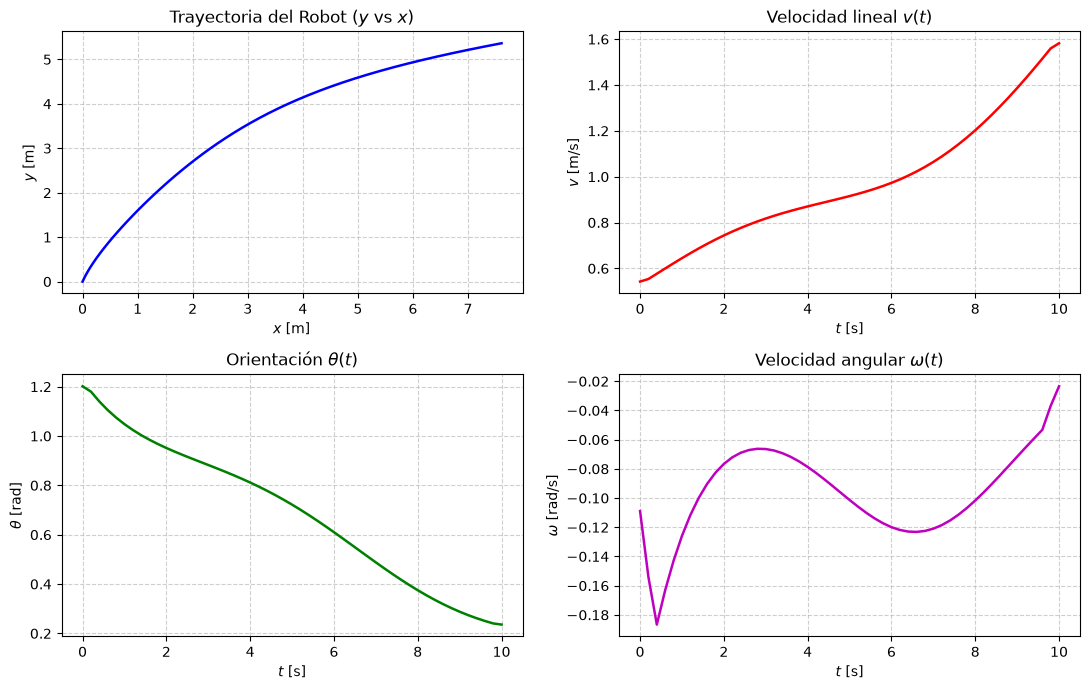

In [8]:
fig, axs = plt.subplots(2, 2, figsize=(11, 7))

# 1. Trayectoria y vs x
axs[0, 0].plot(x, y, 'b-', linewidth=1.8, label="Trayectoria")
axs[0, 0].set_title("Trayectoria del Robot ($y$ vs $x$)")
axs[0, 0].set_xlabel("$x$ [m]")
axs[0, 0].set_ylabel("$y$ [m]")
axs[0, 0].grid(True, linestyle="--", alpha=0.6)

# 2. Velocidad lineal v(t)
axs[0, 1].plot(t, v, 'r-', linewidth=1.8)
axs[0, 1].set_title("Velocidad lineal $v(t)$")
axs[0, 1].set_xlabel("$t$ [s]")
axs[0, 1].set_ylabel("$v$ [m/s]")
axs[0, 1].grid(True, linestyle="--", alpha=0.6)

# 3. Orientación theta(t)
axs[1, 0].plot(t, theta, 'g-', linewidth=1.8)
axs[1, 0].set_title("Orientación $\\theta(t)$")
axs[1, 0].set_xlabel("$t$ [s]")
axs[1, 0].set_ylabel("$\\theta$ [rad]")
axs[1, 0].grid(True, linestyle="--", alpha=0.6)

# 4. Velocidad angular omega(t)
axs[1, 1].plot(t, omega, 'm-', linewidth=1.8)
axs[1, 1].set_title("Velocidad angular $\\omega(t)$")
axs[1, 1].set_xlabel("$t$ [s]")
axs[1, 1].set_ylabel("$\\omega$ [rad/s]")
axs[1, 1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

#### 5.3 Análisis del funcionamiento de `np.gradient`

Al aplicar `np.gradient` sobre los datos de la trayectoria del robot, identificamos cómo maneja la diferenciación numérica en Python:

* **Cálculo vectorizado:** En lugar de recorrer los datos punto a punto con un ciclo `for`, NumPy realiza la operación directamente sobre todo el vector de datos. Esto optimiza el código y reduce el tiempo de ejecución.
* **Comportamiento en los puntos interiores:** Para todos los puntos intermedios (del índice 1 al 49), aplica el método de **diferencias finitas centrales**:
  $$\dot{f}_i \approx \frac{f_{i+1} - f_{i-1}}{t_{i+1} - t_{i-1}}$$
  Este esquema tiene un error de orden $O(h^2)$, lo que nos da un cálculo de velocidad más preciso que una simple resta entre vecinos inmediatos.
* **Manejo de los extremos (inicio y fin):** En el primer punto ($t_0$) y en el último ($t_{50}$), no existen datos a ambos lados. En estos casos, `np.gradient` cambia automáticamente a diferencias unilaterales (hacia adelante al inicio y hacia atrás al final) de segundo orden. Gracias a esto, no perdemos datos y el vector de velocidad conserva la misma longitud de 51 elementos que el vector original de posiciones.

### 6. Parte 3 – C/C++ con GSL

En esta sección implementamos la diferenciación numérica en C/C++ leyendo el archivo CSV. Además, se analiza el uso de la biblioteca **GSL** (`gsl_deriv_central`) frente al procesamiento de datos tabulados.

In [17]:
%%writefile taller_cpp.cpp
#include <iostream>
#include <fstream>
#include <sstream>
#include <vector>
#include <cmath>
#include <iomanip>

using namespace std;

// Función para el desenvolvimiento angular (unwrap)
void unwrap(vector<double>& theta) {
    for (size_t i = 1; i < theta.size(); ++i) {
        double diff = theta[i] - theta[i - 1];
        while (diff > M_PI) {
            theta[i] -= 2.0 * M_PI;
            diff = theta[i] - theta[i - 1];
        }
        while (diff < -M_PI) {
            theta[i] += 2.0 * M_PI;
            diff = theta[i] - theta[i - 1];
        }
    }
}

int main() {
    ifstream file("trayectoria_robot.csv");
    if (!file.is_open()) {
        cerr << "Error al abrir el archivo trayectoria_robot.csv" << endl;
        return 1;
    }

    string line;
    getline(file, line); // Omitir el encabezado "t,x,y"

    vector<double> t, x, y;
    while (getline(file, line)) {
        stringstream ss(line);
        string valT, valX, valY;
        if (getline(ss, valT, ',') && getline(ss, valX, ',') && getline(ss, valY, ',')) {
            t.push_back(stod(valT));
            x.push_back(stod(valX));
            y.push_back(stod(valY));
        }
    }
    file.close();

    size_t N = t.size();
    double h = t[1] - t[0];

    vector<double> vx(N), vy(N), v(N), theta(N), omega(N);

    // 1. Diferencias centrales para vx e vy
    for (size_t i = 1; i < N - 1; ++i) {
        vx[i] = (x[i + 1] - x[i - 1]) / (2.0 * h);
        vy[i] = (y[i + 1] - y[i - 1]) / (2.0 * h);
    }
    // Extremos (diferencias unilaterales)
    vx[0] = (x[1] - x[0]) / h;
    vx[N - 1] = (x[N - 1] - x[N - 2]) / h;
    vy[0] = (y[1] - y[0]) / h;
    vy[N - 1] = (y[N - 1] - y[N - 2]) / h;

    // 2. Magnitud de v y orientación theta
    for (size_t i = 0; i < N; ++i) {
        v[i] = sqrt(vx[i] * vx[i] + vy[i] * vy[i]);
        theta[i] = atan2(vy[i], vx[i]);
    }

    // 3. Aplicar unwrap a theta
    unwrap(theta);

    // 4. Diferencias centrales para omega
    for (size_t i = 1; i < N - 1; ++i) {
        omega[i] = (theta[i + 1] - theta[i - 1]) / (2.0 * h);
    }
    omega[0] = (theta[1] - theta[0]) / h;
    omega[N - 1] = (theta[N - 1] - theta[N - 2]) / h;

    // Mostrar los primeros 3 datos procesados
    cout << fixed << setprecision(6);
    cout << "--- Resultados procesados en C++ ---" << endl;
    cout << "v[:3]     = [" << v[0] << ", " << v[1] << ", " << v[2] << "]" << endl;
    cout << "theta[:3] = [" << theta[0] << ", " << theta[1] << ", " << theta[2] << "]" << endl;
    cout << "omega[:3] = [" << omega[0] << ", " << omega[1] << ", " << omega[2] << "]" << endl;

    return 0;
}

Writing taller_cpp.cpp


In [18]:
!g++ -O2 taller_cpp.cpp -o taller_cpp
!./taller_cpp

--- Resultados procesados en C++ ---
v[:3]     = [0.542613, 0.553893, 0.576827]
theta[:3] = [1.201706, 1.179926, 1.140051]
omega[:3] = [-0.108898, -0.154136, -0.186657]


#### 6.1 Análisis conceptual: `gsl_deriv_central` vs. Datos Tabulados

* **¿Cómo funciona `gsl_deriv_central`?**  
  La función de la biblioteca GSL está diseñada para evaluar **funciones analíticas o continuas** $f(x)$ que se pueden calcular en cualquier punto. Recibe un puntero a la función y evalúa internamente adaptativamente el paso $h$ para minimizar el error de truncamiento y redondeo.

* **¿Por qué en nuestro taller usamos arreglos directos?**  
  En este proyecto trabajamos con **datos tabulados / discretos** provenientes de un CSV (muestras fijas $t_i$ tomadas cada $0.2\text{ s}$). No tenemos una función matemática $f(t)$ que podamos pedirle a C++ que evalúe en puntos intermedios arbitrarios. Por ello, la estrategia correcta es iterar sobre los vectores con un ciclo y aplicar las ecuaciones de diferencias centradas directamente sobre los elementos discretos de los arreglo.

## 7. Comparación de resultados

A continuación se resumen las características principales de cada entorno computacional según los criterios trabajados:

| Criterio | GNU Octave[cite: 3, 4] | Python (NumPy)[cite: 3, 4] | C/C++ con GSL |
| :--- | :--- | :--- | :--- |
| **Carga de datos** | `dlmread('trayectoria_robot.csv', ...)`[cite: 3] | `np.loadtxt("trayectoria_robot.csv", ...)`[cite: 3] | `std::ifstream` analizando el texto con `std::stringstream` |
| **Cálculo de $\dot{x}, \dot{y}$** | Vectores indexados `(3:N) - (1:N-2)`[cite: 3] | `np.gradient(x, t)`[cite: 3] | Bucle `for` con la fórmula $x[i+1] - x[i-1]$[cite: 4] |
| **Cálculo de $v$** | Operaciones vectoriales `sqrt(vx.^2 + vy.^2)`[cite: 3] | `np.sqrt(vx**2 + vy**2)`[cite: 3] | Bucle `for` con `std::sqrt`[cite: 4] |
| **Cálculo de $\theta$** | `atan2(vy, vx)` + `unwrap()`[cite: 2, 3] | `np.unwrap(np.arctan2(vy, vx))`[cite: 2, 3] | `std::atan2` + función `unwrap` personalizada |
| **Cálculo de $\omega$** | Diferencias centrales sobre el vector $\theta$[cite: 3] | `np.gradient(theta, t)`[cite: 3] | Bucle `for` aplicando diferencias finitas sobre `theta`[cite: 4] |
| **Manejo de arreglos** | Vectores nativos de MATLAB/Octave | Arreglos multidimensionales `ndarray` | `std::vector<double>` de la librería estándar |
| **Facilidad de implementación** | Alta (pensado para cálculo matricial)[cite: 2] | Muy alta (sintaxis limpia y métodos integrados)[cite: 3] | Media-Baja (requiere estructurar punteros/bucles) |
| **Control sobre el algoritmo** | Medio | Bajo (NumPy abstrae la operación)[cite: 3] | Total (se tiene control completo sobre memoria e índices) |
| **Tiempo de ejecución** | Intermedio (lenguaje interpretado)[cite: 2] | Rápido (librerías optimizadas internamente en C) | Extremadamente rápido (código compilado nativo) |

### 8. Preguntas de análisis

**1. ¿Qué diferencia existe entre calcular la velocidad lineal a partir de $\dot{x}, \dot{y}$ y calcularla directamente desde diferencias de posición?**
Al derivar primero $x(t)$ e $y(t)$ obtenemos las componentes vectoriales de velocidad $\dot{x}$ e $\dot{y}$. Esto nos da tanto la magnitud real de la velocidad instantánea $v = \sqrt{\dot{x}^2 + \dot{y}^2}$ como la dirección del movimiento $\theta = \text{atan2}(\dot{y}, \dot{x})$. Si diferenciáramos directamente la distancia escalar en la trayectoria, perderíamos la información de la orientación del robot en el plano.

**2. ¿Por qué un error pequeño en $\dot{x}, \dot{y}$ puede producir un efecto mayor al calcular $\omega$?**  
Porque para obtener la velocidad angular $\omega$ realizamos una **doble diferenciación** a partir de las posiciones originales: $(x,y) \rightarrow (\dot{x},\dot{y}) \rightarrow \theta \rightarrow \omega$. Cada proceso de diferenciación numérica amplifica las pequeñas variaciones o ruido en los datos, por lo que cualquier error acumulado en $\dot{x}$ y $\dot{y}$ se magnifica al calcular la derivada de la orientación $\theta$.

**3. ¿Qué ocurre si se reduce $h$ manteniendo un nivel de ruido fijo en las posiciones?**  
Aunque teóricamente reducir el paso $h$ disminuye el error de truncamiento del método numérico, en la práctica, al dividir diferencias pequeñas de datos ruidosos entre un $h$ muy pequeño ($\frac{\Delta f}{h}$), la amplificación del ruido se vuelve crítica y la velocidad calculada resulta en valores inestables.

**4. ¿Por qué $\omega$ requiere especial cuidado con el desenvolvimiento de $\theta$?** 
La función `atan2` arroja ángulos acotados en el intervalo $[-\pi, \pi]$. Si la trayectoria del robot cruza esa frontera, se genera un salto artificial de $2\pi$ (por ejemplo, pasa de $\pi$ a $-\pi$). Si calculamos la derivada $\omega$ sobre ese salto sin usar `unwrap`, obtendremos picos gigantescos e incorrectos de velocidad angular.

### 9. Conclusiones

* La estimación cinemática a partir de datos discretos demuestra que el uso de diferencias centrales es el más adecuado para los puntos anteriores, ya que proporciona un cálculo de velocidad más preciso con un error de orden $O(h^2)$. Sin embargo, el método es sensible a la propagación de errores debido a que la obtención de la velocidad angular implica un proceso de doble diferenciación sucesiva desde las posiciones espaciales originales. Dando como consecuencia que el método dependa obligatoriamente de un acondicionamiento previo de los datos, como el desenvolvimiento angular, sin el cual las discontinuidades de la función arcotangente producirían error al derivar la orientación.   

* De los entornos de programación se concluye que Python, mediante la biblioteca NumPy, resulta ser el entorno con mayor facilidad de implementación gracias a su capacidad de vectorización y a funciones integradas como np.gradient, las cuales aplican automáticamente diferencias centrales y ajustan el cálculo en los extremos sin requerir iteraciones manuales. En la otra mano, el uso de C/C++ exige una programación estructurada de nivel medio-bajo mediante bucles explícitos para iterar sobre los arreglos de datos tabulados, lo que sacrifica la inmediatez en la escritura del código a cambio de otorgar un control total sobre la memoria, los índices matemáticos y brindar tiempos de ejecución extremadamente rápidos.

### 10. Reflexión

1. Reconstrucción de procedimiento

El proceso matemático inicia estimando las componentes de velocidad $\dot{x}$ e $\dot{y}$ al aplicar métodos de diferenciación numérica sobre las muestras discretas de posición. Con estos valores se halla la magnitud de la velocidad lineal
 $v = \sqrt{\dot{x}^2 + \dot{y}^2}$ y la dirección instantánea $\theta = \text{atan2}(\dot{y}, \dot{x})$. Antes de calcular la velocidad angular $\omega$, es indispensable aplicar un desenvolvimiento (unwrap) a $\theta$ para eliminar saltos artificiales de $2\pi$, permitiendo finalmente obtener $\omega = \dot{\theta}$ evaluando la derivada. El error numérico se introduce principalmente por la amplificación del ruido generado por la diferenciación; este efecto es crítico al calcular $\omega$ al ser el resultado de una doble derivada desde la posición, y omitir el desenvolvimiento angular causaría mucho error.

 2. Tranferencia de Aprendizaje

 Al enfrentar datos reales, se debe conservar tanto la secuencia matemática de conversión cinemática como la aplicación estricta del desenvolvimiento angular para garantizar la validez de la orientación. Sin embargo, si se cuenta con una mayor frecuencia de muestreo, aplicar diferencias no es del todo beneficioso porque la división entre un valor temporal tan pequeño aumenta la amplificación de las perturbaciones y genera perfiles de velocidad inestables. Por ello, el criterio principal para seleccionar la herramienta numérica será su capacidad de disminuir la amplificación del ruido. Por ende, se modificaría el procedimiento evitando derivar los datos adquiridos en crudo, optando en su lugar por un pre-filtrado de la señal y prefiriendo métodos numéricos que analicen ventanas de puntos más amplias para lograr suavizar el comportameinto en lugar de solo comparar puntos vecinos y amplificar ruido.